In [23]:
%load_ext autoreload
%autoreload 2
import sys
import os
import copy
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import wandb
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from collections import defaultdict

from src.utils.plotting_style import set_figure_size

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
def get_runs_from_sweep(sweep_id):
    # Initialize wandb API
    api = wandb.Api()

    # Set your wandb project and entity
    entity = "agt-team"
    project = "certified-continual-learning"

    # Query all runs from the specified sweep
    runs = api.sweep(f"{entity}/{project}/{sweep_id}").runs

    print(f"Found {len(runs)} runs in sweep {sweep_id}")

    # Dictionary to store the accuracy matrices
    accuracy_matrices = {}

    # Load accuracy_matrix from each run
    for run in tqdm(runs, desc="Loading accuracy matrices"):
        try:
            # Get run files
            files = run.files()

            # Find accuracy matrix file
            accuracy_file = next(
                (f for f in files if "accuracy_matrix" in f.name), None
            )

            if accuracy_file:
                # Download the file
                accuracy_file.download(exist_ok=True)

                # For W&B table JSON files
                with open(accuracy_file.name, "r") as f:
                    data = json.load(f)
                    # Extract the data from the W&B table format
                    if "data" in data:
                        # Depending on how the table is structured, you might need to adjust this
                        matrix_data = data["data"]
                        accuracy_matrix = np.array(matrix_data)

                        # Store with run name/ID as key
                        accuracy_matrices[run.name] = accuracy_matrix
                    else:
                        print(f"Couldn't parse table data for {run.name}")
            else:
                print(f"No accuracy matrix found for {run.name}")
        except Exception as e:
            print(f"Error loading accuracy matrix for {run.name}: {e}")

    print(f"Successfully loaded {len(accuracy_matrices)} accuracy matrices")


def get_run_from_id(run_id, keys):
    # Initialize wandb API
    api = wandb.Api()

    # Set your wandb project and entity
    entity = "agt-team"
    project = "certified-continual-learning"

    # Get the run by its ID
    try:
        run = api.run(f"{entity}/{project}/{run_id}")
        print(f"Successfully retrieved run: {run.name}")

        # Get run files
        files = run.files()

        results = {}

        for key in keys:
            # Find accuracy matrix file
            accuracy_file = next((f for f in files if key in f.name), None)

            if accuracy_file:
                # Download the file
                accuracy_file.download(exist_ok=True)

                # For W&B table JSON files
                with open(accuracy_file.name, "r") as f:
                    data = json.load(f)
                    # Extract the data from the W&B table format
                    if "data" in data:
                        matrix_data = data["data"]
                        results[key] = np.array(matrix_data)
                    else:
                        print(f"Couldn't parse table data for {run.name}")
            else:
                print(f"No accuracy matrix found for {run.name}")
                f
        return run, results

    except Exception as e:
        print(f"Error retrieving run {run_id}: {e}")
        return None, None


def get_runs_with_tags(tag, keys, n_runs=None):
    """
    Get runs with specific tag and extract specified keys from their files, storing the mean and std of the values.
    """
    # Initialize wandb API
    api = wandb.Api()
    # Set your wandb project and entity
    entity = "agt-team"
    project = "certified-continual-learning"
    # Query runs with the specified tag
    runs = api.runs(
        f"{entity}/{project}",
        {
            "tags": {"$all": tag if isinstance(tag, list) else [tag]},
            "state": "finished",
        },
    )
    print(f"Found {len(runs)} runs with tag '{tag}'")

    # Dictionary to store results for each key
    results = {key: [] for key in keys}

    if n_runs is not None:
        # Limit the number of runs to n_runs
        runs = runs[:n_runs]
        print(f"Limiting to the first {n_runs} runs")

    # Load data from each run
    for run in tqdm(runs, desc=f"Loading data from runs with tag '{tag}'"):
        try:
            # Get run files
            files = run.files()

            for key in keys:
                # Find file matching the current key
                found_file = next((f for f in files if key in f.name), None)

                if found_file:
                    # Download the file
                    found_file.download(exist_ok=True)

                    # Load and parse the data
                    with open(found_file.name, "r") as f:
                        data = json.load(f)
                        if "data" in data:
                            matrix_data = data["data"]
                            results[key].append(np.array(matrix_data))
                        else:
                            print(f"Couldn't parse data for {key} in run {run.name}")
                else:
                    print(f"No file found for {key} in run {run.name}")
        except Exception as e:
            print(f"Error processing run {run.name}: {e}")

    return results

In [49]:
def plot_accuracy_matrix_aggregated(run_results):
    """
    Plot the accuracy averaged across all tasks and the accuracy on task 1.
    """
    fig = plt.figure(
        layout="constrained",
    )  # Adjust size as needed
    width_ratios = [3, 1, 0.2, 0.2, 3, 1, 0.2, 0.2, 3, 1]
    height_ratios = [1, 1]
    gs = gridspec.GridSpec(
        2, 10, figure=fig, width_ratios=width_ratios, height_ratios=height_ratios
    )

    labels = {
        "accuracy_matrix": "PGD w/ LID",
        "accuracy_matrix_sgd": "SGD",
        "accuracy_matrix_ewc": "EWC",
        "accuracy_matrix_lwf": "LwF",
        "accuracy_matrix_ogd": "OGD",
        "accuracy_matrix_icn": "ICN",
    }

    buffer_labels = {
        "accuracy_agem": "A-GEM",
        "accuracy_none": "ZERO buf.",
        "accuracy_small": "SMALL buf.",
        "accuracy_medium": "MEDIUM buf.",
        "accuracy_large": "LARGE buf.",
    }
    cert_color = "black"

    axs = np.empty(
        (2, 6), dtype=object
    )  # We'll pair 6 subplots (3 line + 3 bar, per row)
    # this is kind of a hack to get the titles centered
    titles = [
        "              Class IL                ",
        "             Domain IL            ",
        "              Task IL                ",
    ]

    for l, il_type in enumerate(["class", "domain", "task"]):
        col_base = 2 * l * 2  # 0, 4, 8
        ax_line_top = fig.add_subplot(gs[0, col_base])
        ax_bar_top = fig.add_subplot(gs[0, col_base + 1])
        ax_line_bottom = fig.add_subplot(gs[1, col_base])
        ax_bar_bottom = fig.add_subplot(gs[1, col_base + 1])
        axs[0, 2 * l] = ax_line_top
        axs[0, 2 * l + 1] = ax_bar_top
        axs[1, 2 * l] = ax_line_bottom
        axs[1, 2 * l + 1] = ax_bar_bottom

        ax_line_top.set_title(titles[l], y=1, loc="left", fontsize=8)

        if il_type not in run_results:
            continue

        # ============================ Plot zero-buffer results ============================
        names = [
            "accuracy_matrix_sgd",
            "accuracy_matrix_ewc",
            "accuracy_matrix_lwf",
            "accuracy_matrix_icn",
            "accuracy_matrix",
        ]
        colors = ["C0", "C1", "C2", "C4", "C3"]
        for k, (name, color) in enumerate(zip(names, colors)):
            if name not in run_results[il_type]:
                continue
            accuracy_matrix = run_results[il_type][name]
            avg_accs = [
                [np.mean([am[i][j] for j in range(i + 1)]).item() for i in range(5)]
                for am in accuracy_matrix
            ]
            avg_accs_array = np.array(avg_accs)

            # Calculate mean
            avg_accs = np.mean(avg_accs_array, axis=0)

            # Calculate quartiles for error bars
            q1_avg = np.percentile(avg_accs_array, 10, axis=0)
            q3_avg = np.percentile(avg_accs_array, 90, axis=0)
            avg_accs_yerr = (
                [avg_accs[-1] - q1_avg[-1]],
                [q3_avg[-1] - avg_accs[-1]],
            )
            accuracy_matrix = np.array(accuracy_matrix).mean(axis=0)

            ax_line_top.plot(avg_accs, label=labels[name], color=color, linestyle="-")

            ax_bar_top.bar(
                k,
                avg_accs[-1],
                yerr=avg_accs_yerr[-1],
                capsize=1.0,
                error_kw={"lw": 0.5, "capthick": 0.5, "ecolor": f"grey"},
                color=color,
            )

            if name == "accuracy_matrix" or name == "accuracy_matrix_icn":
                accuracy_matrix[-1, -1] = accuracy_matrix[-2, -1]
                avg_certificates = [
                    np.mean(accuracy_matrix[-1, : i + 1]) for i in range(5)
                ]
                ax_line_top.plot(
                    avg_certificates, linestyle="--", marker="", color=color
                )
                bar = ax_bar_top.bar(
                    k,
                    avg_certificates[-1],
                    width=0.8,
                    color=color,
                    lw=0.0,
                    hatch="//////",
                    edgecolor=cert_color,
                )

        # ============================ Plot buffer results ============================
        buffer_names = [
            "accuracy_agem",
            "accuracy_none",
            "accuracy_small",
            "accuracy_medium",
            "accuracy_large",
        ]
        buffer_colors = ["C5", "C6", "C7", "C8", "C9"]
        for k, (buffer_name, buffer_color) in enumerate(
            zip(buffer_names, buffer_colors)
        ):
            buffer_acc_matrix = run_results["buffer"][il_type][buffer_name]
            buffer_avg_accs = [
                [np.mean([am[i][j] for j in range(i + 1)]).item() for i in range(5)]
                for am in buffer_acc_matrix
            ]
            buffer_avg_accs_array = np.array(buffer_avg_accs)

            # Calculate mean
            buffer_avg_accs = np.mean(buffer_avg_accs_array, axis=0)

            # Calculate quartiles for error bars
            buffer_q1_avg = np.percentile(buffer_avg_accs_array, 10, axis=0)
            buffer_q3_avg = np.percentile(buffer_avg_accs_array, 90, axis=0)
            buffer_avg_accs_yerr = (
                [buffer_avg_accs[-1] - buffer_q1_avg[-1]],
                [buffer_q3_avg[-1] - buffer_avg_accs[-1]],
            )
            buffer_acc_matrix = np.array(buffer_acc_matrix).mean(axis=0)

            ax_line_bottom.plot(
                buffer_avg_accs,
                label=buffer_labels[buffer_name],
                color=buffer_color,
                linestyle="-",
            )

            ax_bar_bottom.bar(
                k,
                buffer_avg_accs[-1],
                yerr=buffer_avg_accs_yerr[-1],
                capsize=1.0,
                error_kw={"lw": 0.5, "capthick": 0.5, "ecolor": f"grey"},
                color=buffer_color,
            )

            if buffer_name != "accuracy_agem":
                buffer_acc_matrix[-1, -1] = buffer_acc_matrix[-2, -1]
                buffer_avg_certificates = [
                    np.mean(buffer_acc_matrix[-1, : i + 1]) for i in range(5)
                ]
                ax_line_bottom.plot(
                    buffer_avg_certificates,
                    linestyle="--",
                    marker="",
                    color=buffer_color,
                )
                bar = ax_bar_bottom.bar(
                    k,
                    buffer_avg_certificates[-1],
                    width=0.8,
                    color=buffer_color,
                    lw=0.0,
                    hatch="//////",
                    edgecolor=cert_color,
                )

        ax_line_top.set_xticks(range(5))
        ax_line_top.set_xticklabels([])
        ax_line_bottom.set_xticks(range(5))
        ax_line_bottom.set_xticklabels([f"{i + 1}" for i in range(5)])
        ax_bar_bottom.set_xticks([1.5])
        ax_bar_top.set_xticks([1.5])
        ax_bar_bottom.set_xticklabels(["Final"])
        ax_bar_top.set_xticklabels([])
        ax_bar_top.set_xlim(-0.8, 4.95)
        ax_bar_bottom.set_xlim(-0.8, 4.95)

    # Labels and limits
    axs[0, 0].set_ylabel("Accuracy\n(Zero Buffer)", fontsize=8)
    axs[1, 0].set_ylabel("Accuracy\n(With Buffer)", fontsize=8)
    axs[1, 0].set_ylim(0.0, 1.05)

    axs[1, 0].set_xlabel("       Train Task           ", loc="left", fontsize=8)
    axs[1, 2].set_xlabel("       Train Task           ", loc="left", fontsize=8)
    axs[1, 4].set_xlabel("       Train Task           ", loc="left", fontsize=8)

    for ax in axs.flatten():
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [])
        ax.set_ylim(0.0, 1.1)

    axs[0, 0].set_yticks([0, 0.25, 0.5, 0.75, 1], ["0", "", "", "", "1"])
    axs[1, 0].set_yticks([0, 0.25, 0.5, 0.75, 1], ["0", "", "", "", "1"])
    # Add grid and ticks
    for ax in axs.flatten():
        # Make minor ticks invisible
        ax.tick_params(which="minor", bottom=False, left=False, right=False, top=False)

    # Axis label
    # fig.supylabel("Accuracy", fontsize=8)
    # Legend
    handles, labels = axs[0, 0].get_legend_handles_labels()
    axs[0, -1].legend(
        handles,
        labels,
        loc="center left",  # Move legend to the right
        bbox_to_anchor=(1.01, 0.5),  # Adjust position as needed
        ncol=1,  # Display labels in a single column
        frameon=True,
        fontsize=8,
    )

    handles, labels = axs[1, 0].get_legend_handles_labels()
    axs[1, -1].legend(
        handles,
        labels,
        loc="center left",  # Move legend to the right
        bbox_to_anchor=(1.01, 0.5),  # Adjust position as needed
        ncol=1,  # Display labels in a single column
        frameon=True,
        fontsize=8,
    )

    set_figure_size(fig, 1, (2, 3), shrink_height=0.8)
    plt.savefig("figures/cifar.pdf", dpi=600)


In [50]:
from collections import defaultdict

results = defaultdict(dict)

In [51]:
keys = ["accuracy_matrix_sgd", "accuracy_matrix_ewc", "accuracy_matrix"]
class_results = get_runs_with_tags("final_cifar_cil_new", keys)
results["class"] = class_results
results["class"]["accuracy_matrix_lwf"] = get_runs_with_tags(
    "final_cifar_cil_lwf", keys=["accuracy_matrix_lwf"]
)["accuracy_matrix_lwf"]
results["class"]["accuracy_matrix_icn"] = get_runs_with_tags(
    "final_cifar_cil_icn", keys=["accuracy_matrix_icn"]
)["accuracy_matrix_icn"]

task_results = get_runs_with_tags("final_cifar_til_new", keys)
results["task"] = task_results
results["task"]["accuracy_matrix_lwf"] = get_runs_with_tags(
    "final_cifar_til_lwf", keys=["accuracy_matrix_lwf"]
)["accuracy_matrix_lwf"]
results["task"]["accuracy_matrix_icn"] = get_runs_with_tags(
    "final_cifar_til_icn", keys=["accuracy_matrix_icn"]
)["accuracy_matrix_icn"]

domain_results = get_runs_with_tags("final_cifar_dil_new", keys)
results["domain"] = domain_results
results["domain"]["accuracy_matrix_lwf"] = get_runs_with_tags(
    "final_cifar_dil_lwf", keys=["accuracy_matrix_lwf"]
)["accuracy_matrix_lwf"]
results["domain"]["accuracy_matrix_icn"] = get_runs_with_tags(
    "final_cifar_dil_icn", keys=["accuracy_matrix_icn"]
)["accuracy_matrix_icn"]

Found 10 runs with tag 'final_cifar_cil_new'


Loading data from runs with tag 'final_cifar_cil_new': 100%|████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.72it/s]


Found 10 runs with tag 'final_cifar_cil_lwf'


Loading data from runs with tag 'final_cifar_cil_lwf': 100%|████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.58it/s]


Found 10 runs with tag 'final_cifar_cil_icn'


...

No file found for accuracy_matrix_sgd in run twilight-silence-5489
No file found for accuracy_matrix_ewc in run twilight-silence-5489


Found 10 runs with tag 'final_cifar_dil_lwf'


Loading data from runs with tag 'final_cifar_dil_lwf': 100%|████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.03it/s]


Found 10 runs with tag 'final_cifar_dil_icn'


Loading data from runs with tag 'final_cifar_dil_icn': 100%|████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.01it/s]


In [52]:
keys = ["accuracy_matrix"]
results["buffer"] = defaultdict(dict)
class_results = get_runs_with_tags(["final_cifar_cil_new"], keys)
results["buffer"]["class"]["accuracy_none"] = class_results["accuracy_matrix"][:5]
class_results = get_runs_with_tags(["buffer_cil", "buffer_small", "final_cifar_buffer"], keys)
results["buffer"]["class"]["accuracy_small"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_cil", "buffer_medium", "final_cifar_buffer"], keys)
results["buffer"]["class"]["accuracy_medium"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_cil", "buffer_large", "final_cifar_buffer"], keys)
results["buffer"]["class"]["accuracy_large"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_cil", "buffer_agem", "final_cifar_buffer"], keys)
results["buffer"]["class"]["accuracy_agem"] = class_results["accuracy_matrix"]

class_results = get_runs_with_tags(["final_cifar_til_new"], keys)
results["buffer"]["task"]["accuracy_none"] = class_results["accuracy_matrix"][:5]
class_results = get_runs_with_tags(["buffer_til", "buffer_small", "final_cifar_buffer"], keys)
results["buffer"]["task"]["accuracy_small"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_til", "buffer_medium", "final_cifar_buffer"], keys)
results["buffer"]["task"]["accuracy_medium"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_til", "buffer_large", "final_cifar_buffer"], keys)
results["buffer"]["task"]["accuracy_large"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_til", "buffer_agem", "final_cifar_buffer"], keys)
results["buffer"]["task"]["accuracy_agem"] = class_results["accuracy_matrix"]


class_results = get_runs_with_tags(["final_cifar_dil_new"], keys)
results["buffer"]["domain"]["accuracy_none"] = class_results["accuracy_matrix"][:5]
class_results = get_runs_with_tags(["buffer_dil", "buffer_small", "final_cifar_buffer"], keys)
results["buffer"]["domain"]["accuracy_small"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_dil", "buffer_medium", "final_cifar_buffer"], keys)
results["buffer"]["domain"]["accuracy_medium"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_dil", "buffer_large", "final_cifar_buffer"], keys)
results["buffer"]["domain"]["accuracy_large"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_dil", "buffer_agem", "final_cifar_buffer"], keys)
results["buffer"]["domain"]["accuracy_agem"] = class_results["accuracy_matrix"]

Found 10 runs with tag '['final_cifar_cil_new']'


Loading data from runs with tag '['final_cifar_cil_new']': 100%|████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.66it/s]


Found 10 runs with tag '['buffer_cil', 'buffer_small', 'final_cifar_buffer']'


Loading data from runs with tag '['buffer_cil', 'buffer_small', 'final_cifar_buffer']': 100%|███████████████████████████████| 10/10 [00:01<00:00,  5.01it/s]


Found 5 runs with tag '['buffer_cil', 'buffer_medium', 'final_cifar_buffer']'


...

Loading data from runs with tag '['buffer_dil', 'buffer_medium', 'final_cifar_buffer']': 100%|████████████████████████████████| 5/5 [00:00<00:00,  5.20it/s]


Found 5 runs with tag '['buffer_dil', 'buffer_large', 'final_cifar_buffer']'


Loading data from runs with tag '['buffer_dil', 'buffer_large', 'final_cifar_buffer']': 100%|█████████████████████████████████| 5/5 [00:01<00:00,  4.55it/s]


Found 5 runs with tag '['buffer_dil', 'buffer_agem', 'final_cifar_buffer']'


Loading data from runs with tag '['buffer_dil', 'buffer_agem', 'final_cifar_buffer']': 100%|██████████████████████████████████| 5/5 [00:01<00:00,  4.42it/s]


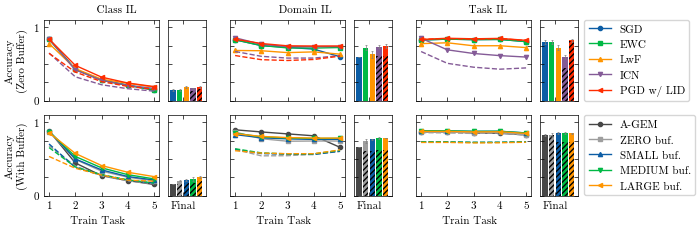

In [54]:
plot_accuracy_matrix_aggregated(results)